# Strategic Customer Segmentation: From Behavioral Patterns to Retention Strategy
**Author:** Alex Cheung  
**Objective:** To move beyond simple churn prediction by identifying distinct customer archetypes using **K-Means Clustering**, allowing for personalized marketing and prioritized retention efforts.

In [20]:
import pandas as pd
# Read data
df = pd.read_parquet('clean_df.parquet')

### 🛠 Phase 1: Data Preparation & Feature Scaling
K-Means relies on **Euclidean Distance**. Because features like `TotalCharges` (0-8000) have a much larger scale than `tenure` (0-72), scaling is mandatory to prevent biased clustering.

* **Selected Features:** `tenure`, `MonthlyCharges`, `TotalCharges` (The Value Triad).
* **Preprocessing:** Handled missing values in `TotalCharges` and applied `StandardScaler` to ensure each feature contributes equally to the distance calculation.

Handled missing TotalCharges values using median imputation to address data sparsity in new customer accounts (tenure = 0) while preserving overall dataset completeness.

In [21]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 1. Feature Selection
features = ['tenure', 'MonthlyCharges', 'TotalCharges']
X = df[features].copy()

# NAN handling in TotalCharges
X['TotalCharges'] = pd.to_numeric(X['TotalCharges'], errors='coerce')
X['TotalCharges'] = X['TotalCharges'].fillna(X['TotalCharges'].median())

In [22]:
# 2. StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit X_scaled back to DataFrame 
X_scaled_df = pd.DataFrame(X_scaled, columns=features)
print(X_scaled_df.head())

     tenure  MonthlyCharges  TotalCharges
0 -1.280248       -1.161694     -0.994194
1  0.064303       -0.260878     -0.173740
2 -1.239504       -0.363923     -0.959649
3  0.512486       -0.747850     -0.195248
4 -1.239504        0.196178     -0.940457


### 📈 Phase 2: Finding the Optimal Number of Clusters
I utilized the **Elbow Method** to determine the ideal $K$. By plotting the **Sum of Squared Errors (SSE)** against the number of clusters, I looked for the "elbow"—the point where adding another cluster yields diminishing returns in reducing variance.

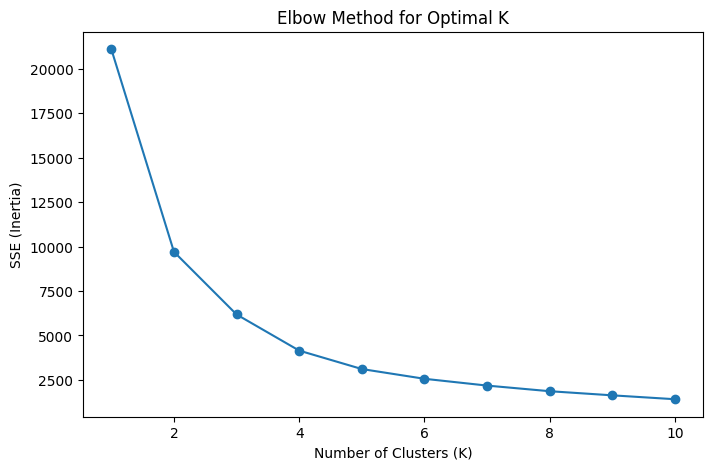

In [23]:
sse = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    sse.append(kmeans.inertia_) # inertia_ = SSE

# SSE plot
plt.figure(figsize=(8, 5))
plt.plot(k_range, sse, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('SSE (Inertia)')
plt.show()

The chart indicated SSE decrease slower (Elbow) when K=3

While $K=4$ showed a further decrease in SSE, I selected $K=3$ to balance model performance with business interpretability. Choosing three clusters provides the most distinct, actionable customer personas, ensuring that marketing strategies remain manageable and operationally efficient.

### 📊 Phase 3: Cluster Profiling & Persona Development
Based on the centroid analysis, three clear customer segments emerged:

1. **Cluster 0: "Budget Mainstays"** (Mid Tenure, Low Spend). Reliable but low-revenue.
2. **Cluster 1: "Flagship Loyalists"** (High Tenure, High Spend). The highest LTV (Lifetime Value) group.
3. **Cluster 2: "High-Value Newcomers"** (Low Tenure, High Spend). **Critical Group.**

| Metric | Cluster 0 | Cluster 1 | Cluster 2 |
| :--- | :--- | :--- | :--- |
| **Tenure (Avg)** | 30 months | 59 months | 13 months |
| **Monthly Bill** | ~$26 | ~$90 | ~$75 |
| **Risk Level** | Low | Low | **CRITICAL** |

In [24]:
# cluster in 3 groups (K=3)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Features analysis
analysis = df.groupby('Cluster')[features].mean()
print(analysis)

            tenure  MonthlyCharges  TotalCharges
Cluster                                         
0        29.620642       26.632241    815.255649
1        58.570323       89.743719   5249.427014
2        13.262668       74.965760   1031.878782


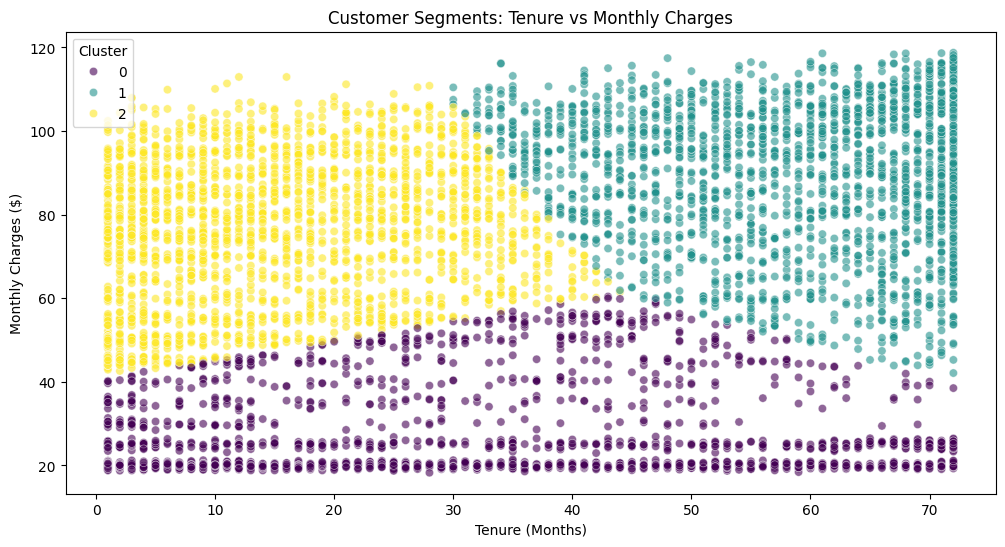

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

# set up plot area
plt.figure(figsize=(12, 6))

# scatter plot
#sns.scatterplot(data=df, x='tenure', y='MonthlyCharges', 
#                hue='Cluster', style='Churn', size='TotalCharges',
#                palette='viridis', alpha=0.6)
sns.scatterplot(data=df, x='tenure', y='MonthlyCharges', hue='Cluster', 
                palette='viridis', alpha=0.6)

plt.title('Customer Segments: Tenure vs Monthly Charges')
plt.xlabel('Tenure (Months)')
plt.ylabel('Monthly Charges ($)')
plt.legend(title='Cluster')
plt.show()

Cluster 1: The "Golden Goose" (High Tenure, High Spend)
Data: Tenure ~58 months, Monthly ~$89.

Comment: These are the most valuable customers. They use premium services (likely Fiber optic and multiple add-ons) and have stayed for 5 years.

Risk: Low churn, but high impact if they do leave.

Strategy: Loyalty programs and "Surprise & Delight" rewards.


Cluster 2: The "At-Risk High Rollers" (Low Tenure, High Spend)
Data: Tenure ~13 months, Monthly ~$75.

Comment: This is the most "dangerous" group. They are paying for expensive plans but haven't been with the company long enough to be "sticky."

Strategy: Aggressive retention. Move them to a 1-year or 2-year contract with a discount.


Cluster 0: The "Budget Minimalists" (Mid Tenure, Low Spend)
Data: Tenure ~29 months, Monthly ~$26.

Comment: These are likely customers on basic DSL or "Phone-only" plans. They are stable (2.5 years) but low revenue.

Strategy: Up-selling. Test if they are interested in a basic streaming bundle to increase that $26 average.

### 🔍 Phase 4: Validating Segments against Churn Behavior
Does the clustering align with real-world outcomes? I cross-referenced the unsupervised clusters with the actual `Churn` labels to calculate the **Churn Probability per Segment**.

In [26]:
# Compare Churn Rate across clusters
df.groupby('Cluster')['Churn'].value_counts(normalize=True).unstack()

Churn,0,1
Cluster,,
0,0.876801,0.123199
1,0.846154,0.153846
2,0.528316,0.471684


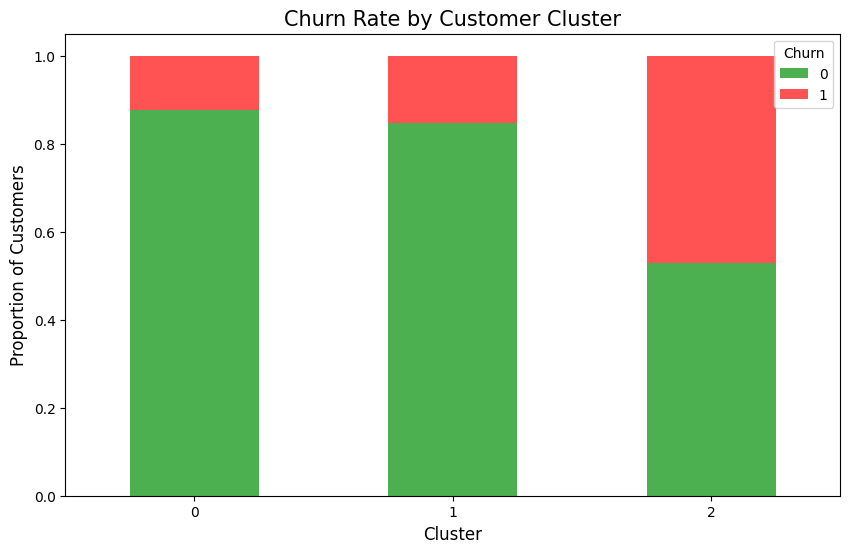

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

# setup crosstab
ct = pd.crosstab(df['Cluster'], df['Churn'], normalize='index')

# Stack bar chart
ct.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#4CAF50', '#FF5252'])
plt.title('Churn Rate by Customer Cluster', fontsize=15)
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Proportion of Customers', fontsize=12)
plt.legend(title='Churn', loc='upper right')
plt.xticks(rotation=0)
plt.show()

## 🚀 Strategic Conclusion & Recommendations
The analysis revealed that **Cluster 2 (High-Value Newcomers)** is the primary driver of churn, with a staggering **47.2% churn rate**. 

### **Proposed Actions:**
* **Retention Priority:** Implement a "High-Touch" onboarding program for Cluster 2 customers within their first 12 months.
* **Contract Conversion:** Offer targeted incentives to move Cluster 2 from "Month-to-Month" to "One-Year" contracts.
* **Upsell Strategy:** Cluster 0 (Budget) shows high stability; they are the best candidates for "Lite" add-on services to increase revenue without risking churn.